<center><font size = 10> Sentiment Analysis of Stock News Using Generative AI and NLP Embeddings </font>

<center><p float="center">
  <img src="https://eu-images.contentstack.com/v3/assets/bltd74737b907a31bbb/blt47d314fe999f1069/69bb8c95dd148f845dc997bd/market-sentiment-featured-og.jpg?format=pjpg&auto=webp&width=1536&quality=75&branch=main" width="720"/>
</p></center>

## **Problem Statement**

### Business Context

The prices of the stocks of companies listed under a global exchange are influenced by a variety of factors, with the company's financial performance, innovations and collaborations, and market sentiment being factors that play a significant role. News and media reports can rapidly affect investor perceptions and, consequently, stock prices in the highly competitive financial industry. With the sheer volume of news and opinions from a wide variety of sources, investors and financial analysts often struggle to stay updated and accurately interpret its impact on the market. As a result, investment firms need sophisticated tools to analyze market sentiment and integrate this information into their investment strategies.

### Problem Definition

With an ever-rising number of news articles and opinions, an investment startup aims to leverage artificial intelligence to address the challenge of interpreting stock-related news and its impact on stock prices. They have collected historical daily news for a specific company listed under NASDAQ, along with data on its daily stock price and trade volumes.

As a member of the Data Science and AI team in the startup, you have been tasked with developing an AI-driven sentiment analysis system that will automatically process and analyze news articles to gauge market sentiment, and summarizing the news at a weekly level to enhance the accuracy of their stock price predictions and optimize investment strategies. This will empower their financial analysts with actionable insights, leading to more informed investment decisions and improved client outcomes.

### Data Dictionary

* `Date` : The date the news was released
* `News` : The content of news articles that could potentially affect the company's stock price
* `Open` : The stock price (in \$) at the beginning of the day
* `High` : The highest stock price (in \$) reached during the day
* `Low` :  The lowest stock price (in \$) reached during the day
* `Close` : The adjusted stock price (in \$) at the end of the day
* `Volume` : The number of shares traded during the day
* `Label` : The sentiment polarity of the news content
    * 1: positive
    * 0: neutral
    * -1: negative

## **Installing and Importing the necessary libraries**

In [1]:
# installing the sentence-transformers and gensim libraries for word embeddings
!pip install numpy==1.26.4 \
             scikit-learn==1.6.1 \
             scipy==1.13.1 \
             gensim==4.3.3 \
             sentence-transformers==3.4.1 \
             pandas==2.2.2

**In simple terms:** Installs the exact library versions (numpy, gensim, sentence-transformers, etc.) needed for the embeddings and models used later.

In [2]:
# to read and manipulate the data
import numpy as np
import pandas as pd
pd.set_option('max_colwidth', None)    # setting column to the maximum column width as per the data

# to visualise data
import matplotlib.pyplot as plt
import seaborn as sns

# To import Word2Vec
from gensim.models import Word2Vec

# Deep Learning library
import torch

# to load transformer models
from sentence_transformers import SentenceTransformer
from transformers import T5Tokenizer, T5ForConditionalGeneration, pipeline

# To split data into train and test sets
from sklearn.model_selection import train_test_split

# To build a Random Forest model
from sklearn.ensemble import RandomForestClassifier

# To compute metrics to evaluate the model
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# to ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Import TensorFlow and Keras for deep learning model building.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

**In simple terms:** Imports all the tools needed — pandas/numpy for data handling, matplotlib/seaborn for plots, Word2Vec and Sentence Transformers for embeddings, and sklearn/TensorFlow for building and evaluating models.

## **Loading the dataset**

In [3]:
# Mount Google Drive to the /content/drive directory to access the files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**In simple terms:** Connects Google Drive to Colab so the dataset file can be accessed.

In [4]:
# loading data into a pandas dataframe
News = pd.read_csv("/content/drive/MyDrive/GenAi/stock_news.csv")

**In simple terms:** Loads the stock news CSV file from Google Drive into a DataFrame called `News`.

In [5]:
# creating a copy of the data
data = News.copy()

**In simple terms:** Makes a working copy (`data`) of the raw data so the original stays unchanged.

## **Data Overview**

###**Checking the first 5 rows**

In [6]:
data.head()

,Date,News,Open,High,Low,Close,Volume,Label
0,2019-01-02,"The tech sector experienced a significant decline in the aftermarket following Apple's Q1 revenue warning. Notable suppliers, including Skyworks, Broadcom, Lumentum, Qorvo, and TSMC, saw their stocks drop in response to Apple's downward revision of its revenue expectations for the quarter, previously announced in January.",41.740002,42.244999,41.482498,40.246914,130672400,-1
1,2019-01-02,"Apple lowered its fiscal Q1 revenue guidance to $84 billion from earlier estimates of $89-$93 billion due to weaker than expected iPhone sales. The announcement caused a significant drop in Apple's stock price and negatively impacted related suppliers, leading to broader market declines for tech indices such as Nasdaq 10",41.740002,42.244999,41.482498,40.246914,130672400,-1
2,2019-01-02,"Apple cut its fiscal first quarter revenue forecast from $89-$93 billion to $84 billion due to weaker demand in China and fewer iPhone upgrades. CEO Tim Cook also mentioned constrained sales of Airpods and Macbooks. Apple's shares fell 8.5% in post market trading, while Asian suppliers like Hon",41.740002,42.244999,41.482498,40.246914,130672400,-1
3,2019-01-02,"This news article reports that yields on long-dated U.S. Treasury securities hit their lowest levels in nearly a year on January 2, 2019, due to concerns about the health of the global economy following weak economic data from China and Europe, as well as the partial U.S. government shutdown. Apple",41.740002,42.244999,41.482498,40.246914,130672400,-1
4,2019-01-02,"Apple's revenue warning led to a decline in USD JPY pair and a gain in Japanese yen, as investors sought safety in the highly liquid currency. Apple's underperformance in Q1, with forecasted revenue of $84 billion compared to analyst expectations of $91.5 billion, triggered risk aversion mood in markets",41.740002,42.244999,41.482498,40.246914,130672400,-1


###**Checking the last 5 rows**

In [7]:
data.tail()

,Date,News,Open,High,Low,Close,Volume,Label
344,2019-04-30,"Media mogul Oprah Winfrey, known for influencing millions with her opinions on diets and books, is considering which Democratic presidential candidate to endorse in 2020. She told the Hollywood Reporter she's ""quietly figuring out where I'm going to use my voice"" and will make a clear announcement",50.764999,50.849998,49.7775,48.70879,186139600,-1
345,2019-04-30,"European shares fell on Tuesday, with banks underperforming amid a decline in China's manufacturing activity and awaiting euro zone economic growth numbers. The pan-European STOXX 600 index dropped 0.7% while major indices fell except London's FTSE 100. Danske Bank plunged",50.764999,50.849998,49.7775,48.70879,186139600,-1
346,2019-04-30,"This article reports that the S&P 500 reached another record high close on Tuesday, marking its best four-month stretch since late 2010. Apple's strong quarterly results and positive earnings forecast helped ease concerns about the bull run's sustainability, despite a revenue miss from Google parent Alphabet. The",50.764999,50.849998,49.7775,48.70879,186139600,-1
347,2019-04-30,"The Federal Reserve is anticipated to keep interest rates unchanged in their upcoming meeting, with a likelihood of a rate cut expected later this year. The Fed Chairman's press conference may provide significant market impact as investors seek insights on economic growth and inflation. Apple's earnings report exceeded expectations, leading to a post-market surge in shares, while",50.764999,50.849998,49.7775,48.70879,186139600,-1
348,2019-04-30,"In the first quarter, South Korea's Samsung Electronics reported its weakest profit in over two years due to falls in chip prices and slowing demand for display panels. The tech giant expects improved results in the second half of 2019, driven by a pickup in memory chip and smartphone sales. However, memory chip",50.764999,50.849998,49.7775,48.70879,186139600,0


###**Checking the shape of the data**

In [8]:
data.shape

(349, 8)

**In simple terms:** The dataset has **349 rows and 8 columns**.

###**Checking for missing values**

In [9]:
data.isnull().sum()

,0
Date,0
News,0
Open,0
High,0
Low,0
Close,0
Volume,0
Label,0


**In simple terms:** There are **no missing values** in any column.

### **Checking for duplicate values**

In [10]:
#checking for duplicate values
data.duplicated().sum()

0

**In simple terms:** There are **0 duplicate rows** in the dataset.

## **Exploratory Data Analysis**

In [11]:
# To display the structure of data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    349 non-null    object 
 1   News    349 non-null    object 
 2   Open    349 non-null    float64
 3   High    349 non-null    float64
 4   Low     349 non-null    float64
 5   Close   349 non-null    float64
 6   Volume  349 non-null    int64  
 7   Label   349 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 21.9+ KB


**In simple terms:** Confirms 349 entries, 8 columns, with `Date`/`News` as text (object) and price columns as numeric — `Date` is not yet a proper date type.

In [12]:
#converting object column 'Date' to datetime
data['Date'] = pd.to_datetime(data['Date'])

**In simple terms:** Converts the `Date` column from text into an actual datetime format.

In [13]:
# To ensure the data type of Date
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    349 non-null    datetime64[ns]
 1   News    349 non-null    object        
 2   Open    349 non-null    float64       
 3   High    349 non-null    float64       
 4   Low     349 non-null    float64       
 5   Close   349 non-null    float64       
 6   Volume  349 non-null    int64         
 7   Label   349 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(2), object(1)
memory usage: 21.9+ KB


**In simple terms:** Confirms `Date` is now correctly stored as `datetime64`.

<center><p float="center">
  <img src="https://i.postimg.cc/BQCXd8zw/data-overview.jpg" width="720"/>
</p></center>

In [14]:
# summary statistics for each numeric column
data.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,349,2019-02-16 16:05:30.085959936,2019-01-02 00:00:00,2019-01-14 00:00:00,2019-02-05 00:00:00,2019-03-22 00:00:00,2019-04-30 00:00:00,NaN
Open,349.0,46.229233,37.567501,41.740002,45.974998,50.7075,66.817497,6.442817
High,349.0,46.700458,37.817501,42.244999,46.025002,50.849998,67.0625,6.507321
Low,349.0,45.745394,37.305,41.482498,45.639999,49.7775,65.862503,6.391976
Close,349.0,44.926317,36.254131,40.246914,44.596924,49.11079,64.805229,6.398338
Volume,349.0,128948236.103152,45448000.0,103272000.0,115627200.0,151125200.0,244439200.0,43170314.918964
Label,349.0,-0.054441,-1.0,-1.0,0.0,0.0,1.0,0.715119


**In simple terms:** Summary stats show average Open ≈ \$46.2, average Volume ≈ 129M shares, and the average sentiment `Label` is slightly negative (≈ -0.05), meaning news sentiment is fairly balanced but leans mildly negative overall.

<center><p float="center">
  <img src="https://i.postimg.cc/JhYXSyGQ/summary-statistics-numeric-columns.png" width="720"/>
</p></center>

### **Univariate Analysis**

* Distribution of individual variables
* Compute and check the distribution of the length of news content
* Monthwise Analysis

### **Distribution of Sentiment polarity and all Numeric Variables**

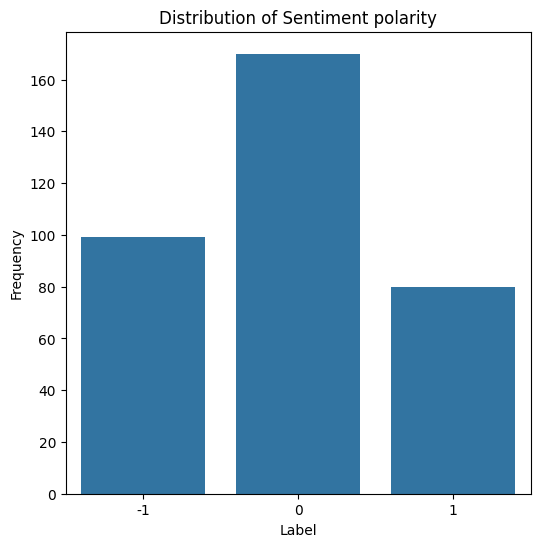

In [15]:
# Distribution of sentiment polarity
plt.figure(figsize=(6, 6))  # Set the figure size
sns.countplot(x = 'Label', data = data) # Create countplot
plt.title('Distribution of Sentiment polarity') # Set the title of the histogram
plt.xlabel('Label') # Set the label for the x-axis
plt.ylabel('Frequency') # Set the label for the y-axis
plt.show() # Display the plot

**In simple terms:** Plots how many news articles fall into each sentiment class (negative/neutral/positive) as a count plot.

In [16]:
numeric_col = [['Open','skyblue'],['High','yellow'],['Low','orange'],['Close','red'],['Volume','blue'],['Label','green']]

**In simple terms:** Defines the numeric price columns (Open, High, Low, Close, Volume) and a color for each, to reuse in the plots below.

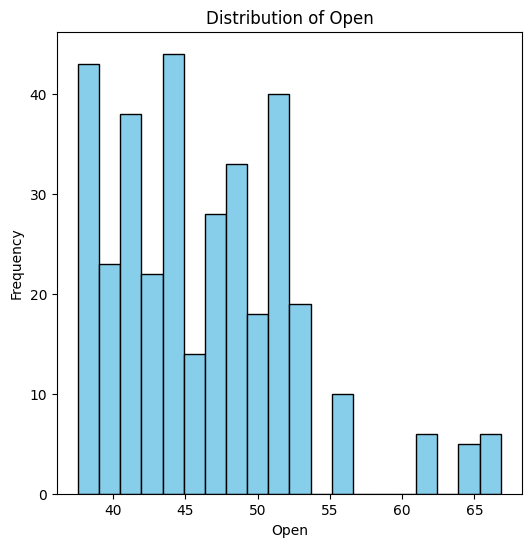

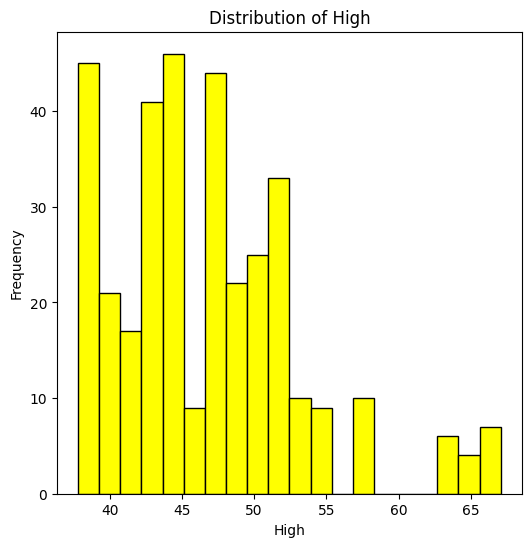

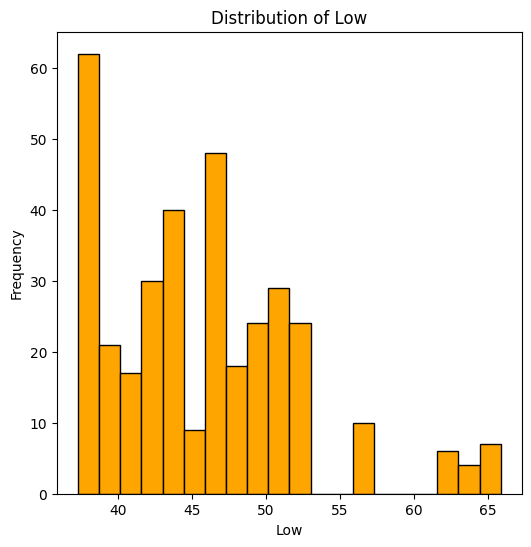

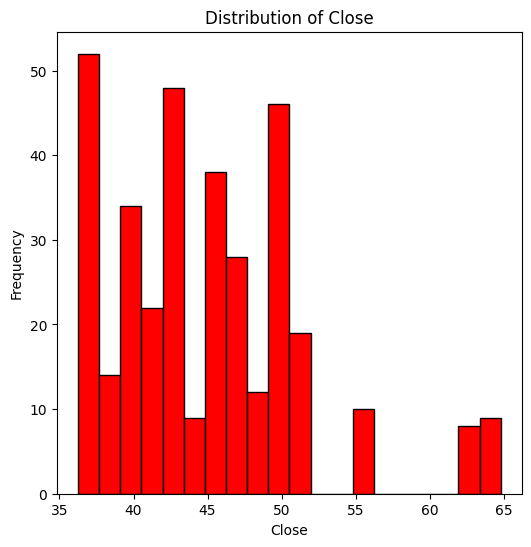

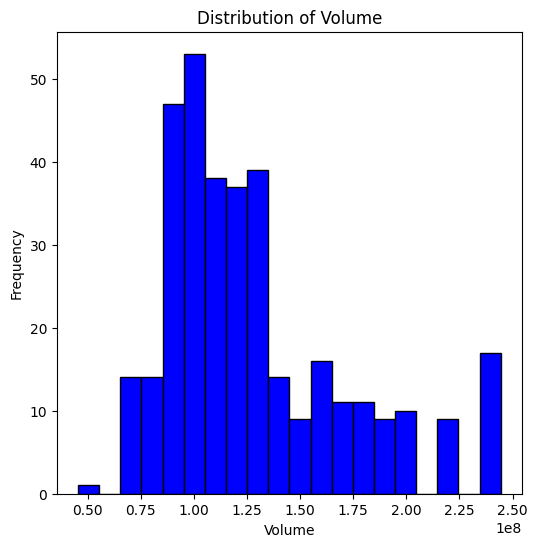

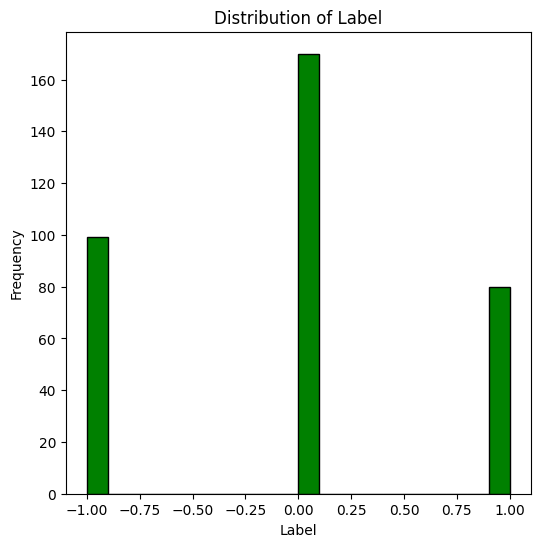

In [17]:
# Plot Distribution of all Numeric variables
for col, vis in numeric_col:
  plt.figure(figsize=(6, 6))  # Set the figure size
  plt.hist(data[col], bins=20, color=vis, edgecolor='black')
  plt.title(f'Distribution of {col}') # Set the title of the histogram
  plt.xlabel(col) # Set the label for the x-axis
  plt.ylabel('Frequency') # Set the label for the y-axis
  plt.show() # Display the plot

**In simple terms:** Plots the distribution (histogram) of each numeric price variable to see its spread and shape.

### **Distribution of the length of news content**

In [18]:
# Compute length of news content (in words)
data['News_length'] = data['News'].apply(lambda x: len(x.split()))
# Summary statistics of news length
data['News_length'].describe()

,News_length
count,349.000000
mean,48.349570
std,5.717324
min,18.000000
25%,45.000000
50%,49.000000
75%,52.000000
max,60.000000


**In simple terms:** Calculates the word count of each news article and stores it in a new `News_length` column.

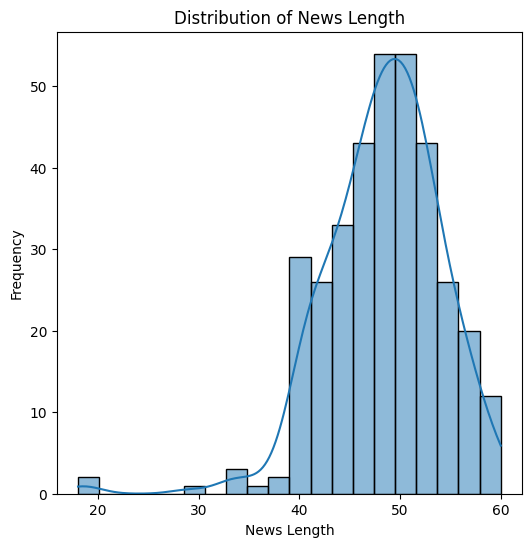

In [19]:
# Plot distribution
plt.figure(figsize=(6, 6))
sns.histplot(data['News_length'], bins=20, kde=True)
plt.title('Distribution of News Length')
plt.xlabel('News Length')
plt.ylabel('Frequency')
plt.show()


**In simple terms:** Plots the distribution of news article lengths (word counts) as a histogram.

### **Monthwise Analysis**

In [20]:
#Create a YearMonth column
data['YearMonth'] = data['Date'].dt.to_period('M').astype(str)

# Group by YearMonth and calculate averages
monthwise_avg = (
    data.groupby('YearMonth')[['High', 'Low', 'Open', 'Close','Volume']]
      .mean()
      .reset_index()
)

monthwise_avg

,YearMonth,High,Low,Open,Close,Volume
0,2019-01,44.024216,43.023629,43.550407,42.252099,1.393266e+08
1,2019-02,48.140754,47.365095,47.674387,46.376751,1.013622e+08
2,2019-03,48.007575,46.920933,47.566045,46.139134,1.413169e+08
3,2019-04,51.150357,50.304246,50.650277,49.462640,1.116555e+08


**In simple terms:** Creates a `YearMonth` column and computes the average High/Low/Open/Close/Volume for each month.

In [21]:
numeric_col1 = [['High','black'],['Low','orange'],['Open','grey'],['Close','red']]

**In simple terms:** Sets up the price columns and colors to plot the monthwise trend lines below.

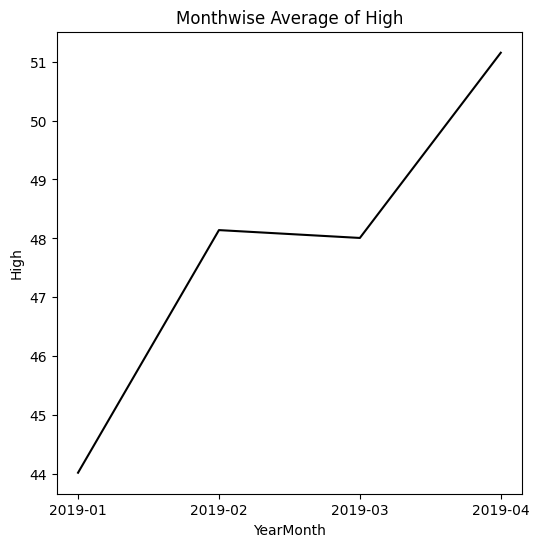

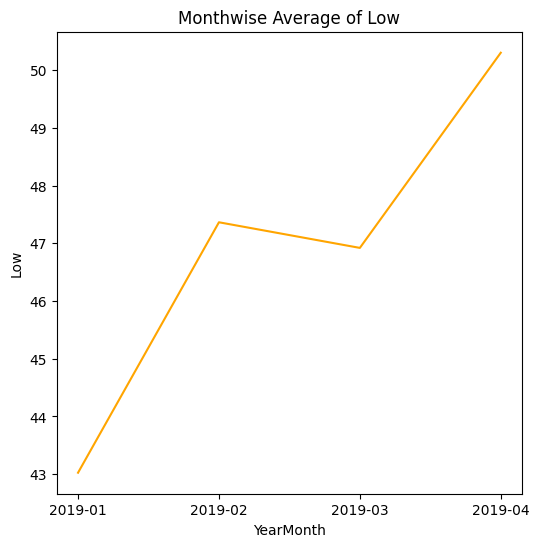

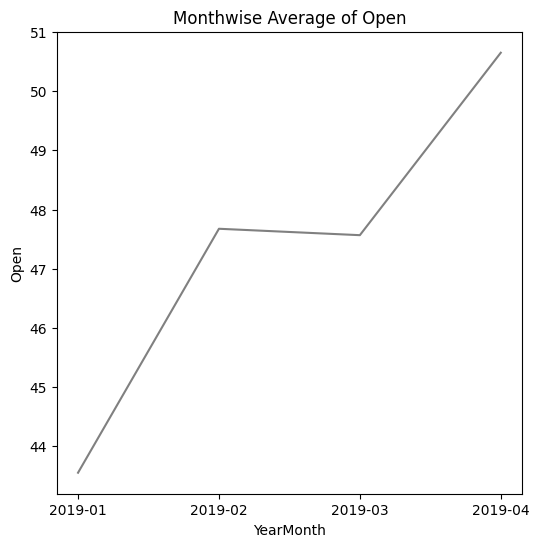

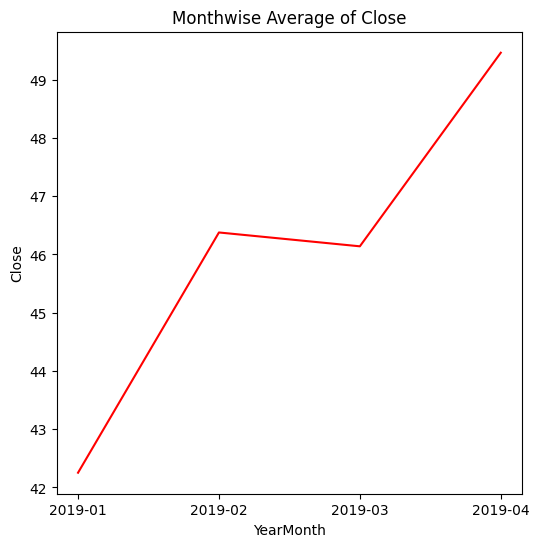

In [22]:
# plot the monthwise averages of all price variables for better visualization
for col, vis in numeric_col1:
  plt.figure(figsize=(6,6))
  sns.lineplot(x='YearMonth', y=col, data=monthwise_avg, color=vis)
  plt.title(f'Monthwise Average of {col}')
  plt.xlabel('YearMonth')
  plt.ylabel(col)
  plt.show()

**In simple terms:** Plots how average High/Low/Open/Close prices trend across each month — prices rise steadily from January to April 2019.

* Price Trend (High, Low, Open, Close) shows that there is a steady increase in all price measures from January to April 2019.

Text(0, 0.5, 'Volume')

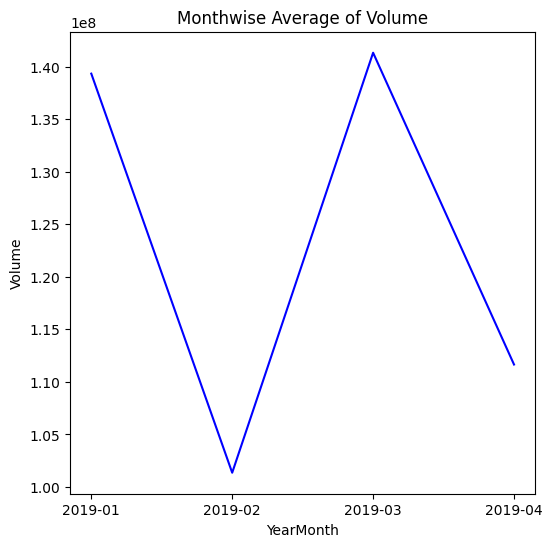

In [23]:
#plot the trend of monthwise averages in Volume
plt.figure(figsize=(6,6))
sns.lineplot(x='YearMonth', y='Volume', data=monthwise_avg, color='blue')
plt.title('Monthwise Average of Volume')
plt.xlabel('YearMonth')
plt.ylabel('Volume')

**In simple terms:** Plots the month-wise trend of average trading Volume as a line chart.

Text(0, 0.5, 'Volume')

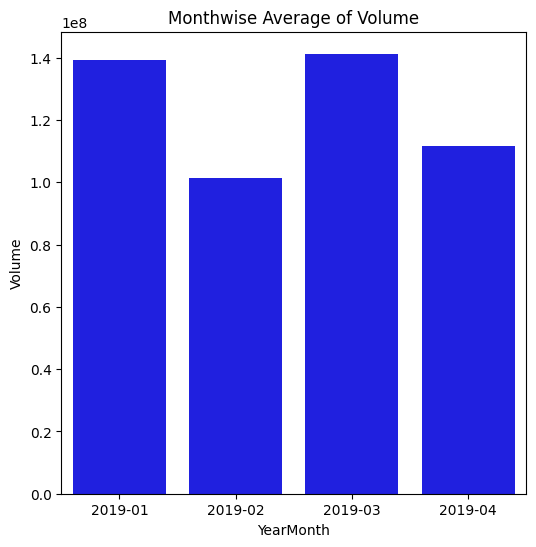

In [24]:
# Bar plot of the monthwise averages in Volume
plt.figure(figsize=(6,6))
sns.barplot(x='YearMonth', y='Volume', data=monthwise_avg, color='blue')
plt.title('Monthwise Average of Volume')
plt.xlabel('YearMonth')
plt.ylabel('Volume')

**In simple terms:** Plots the month-wise average trading Volume as a bar chart.

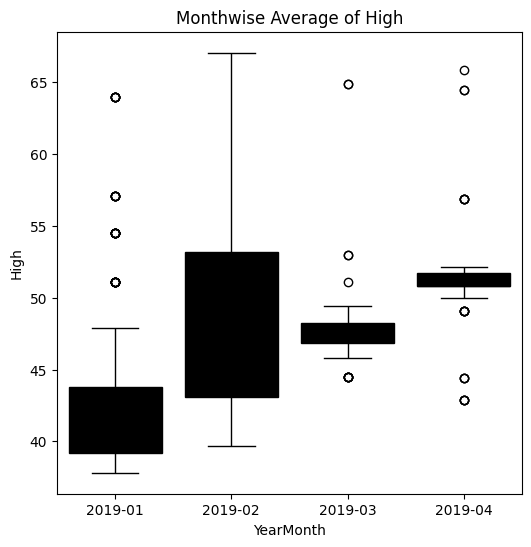

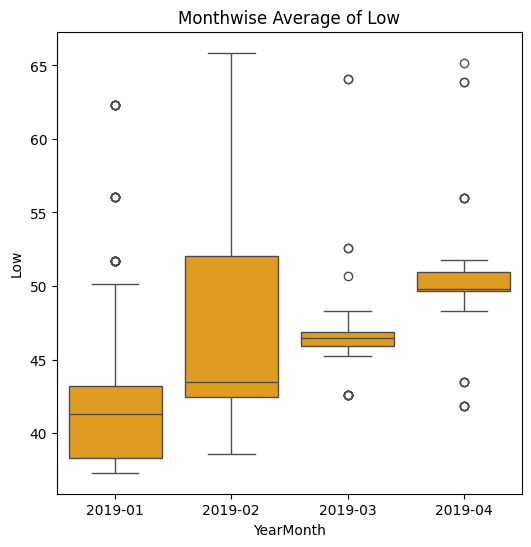

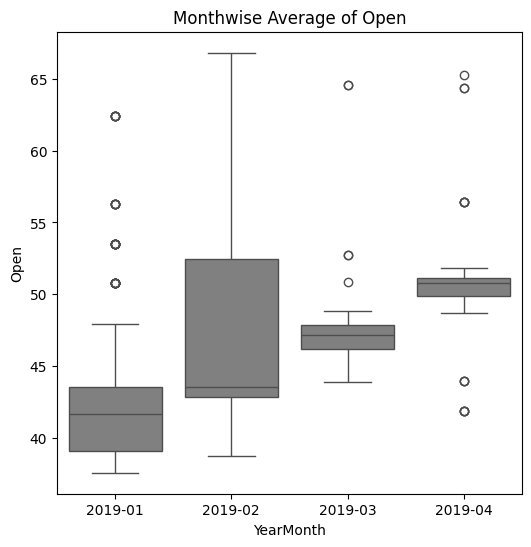

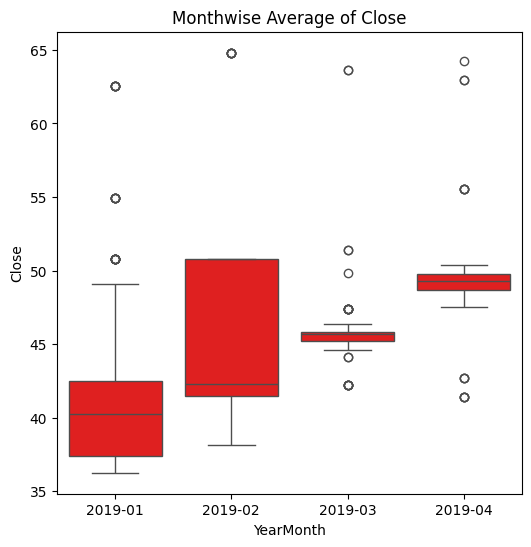

In [25]:
# Boxplot to identify outliers
for col, vis in numeric_col1:
  plt.figure(figsize=(6,6))
  sns.boxplot(x='YearMonth', y=col, data=data, color=vis)
  plt.title(f'Monthwise Average of {col}')
  plt.xlabel('YearMonth')
  plt.ylabel(col)
  plt.show()

**In simple terms:** Draws boxplots for each price variable to spot potential outliers.

### **Bivariate Analysis**

* Correlation
* Sentiment Polarity vs Price
* Date vs Price
* Distribution of News Length Across Sentiment Categories



### **Correlation**

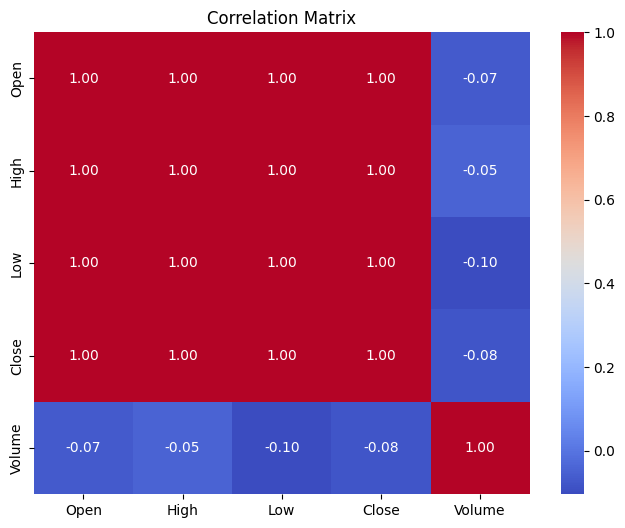

In [26]:
num_col = ['Open','High','Low','Close','Volume']

# Correlation matrix to check if variables move together or have correlations
plt.figure(figsize=(8,6))
sns.heatmap(data[num_col].corr(), annot=True, cmap='coolwarm',fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

**In simple terms:** Builds and visualizes a correlation heatmap between Open, High, Low, Close, and Volume, showing how strongly these price variables move together.

### **Sentiment Polarity vs Price**

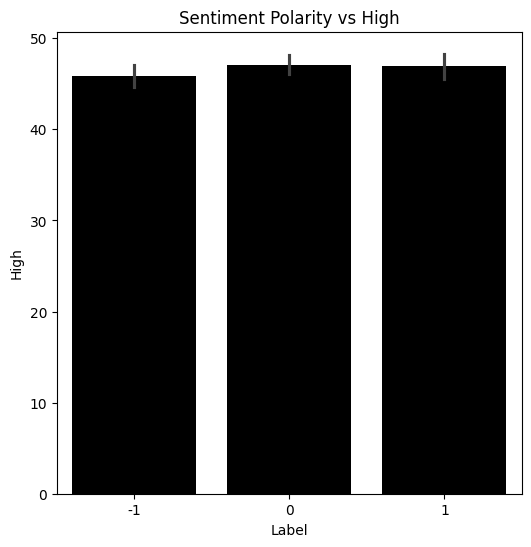

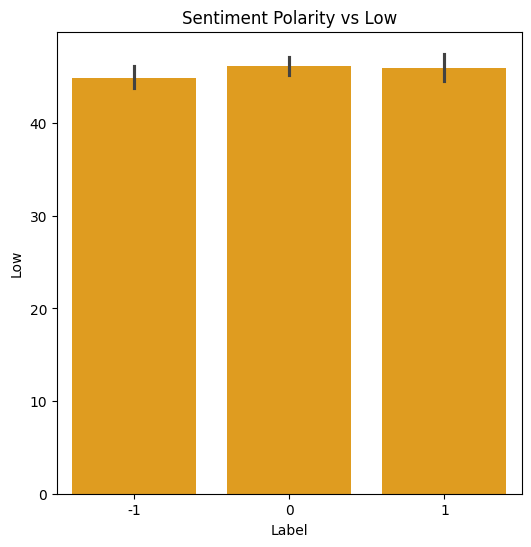

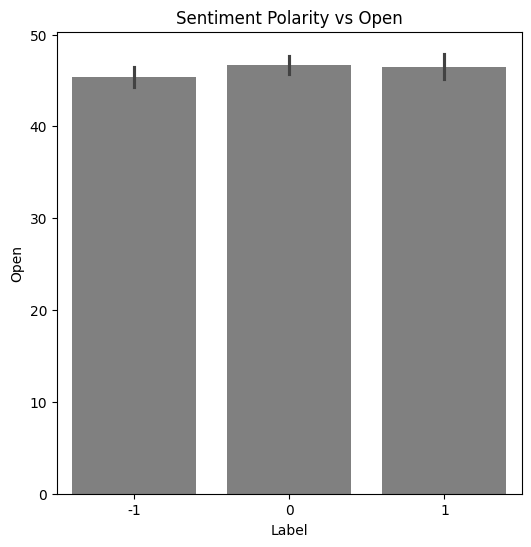

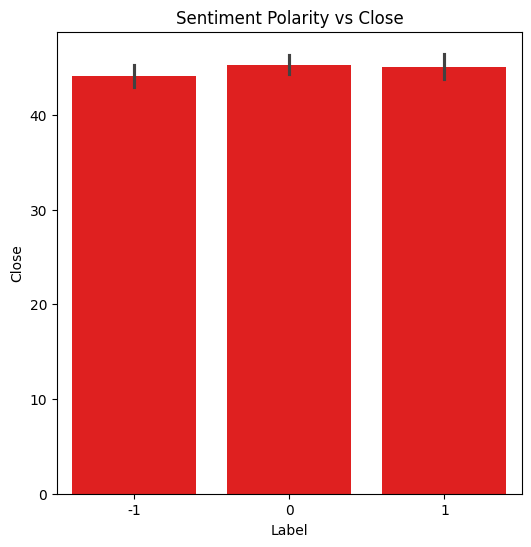

In [27]:
#Sentiment Polarity with all numeric variables
for col, vis in numeric_col1:
  plt.figure(figsize=(6,6))
  sns.barplot(x='Label', y=col, data=data, color=vis)
  plt.title(f'Sentiment Polarity vs {col}')
  plt.xlabel('Label')
  plt.ylabel(col)
  plt.show()


**In simple terms:** Plots sentiment polarity against each price variable to check if news sentiment relates to price movement.

### **Time Series Analysis (Date vs Price)**

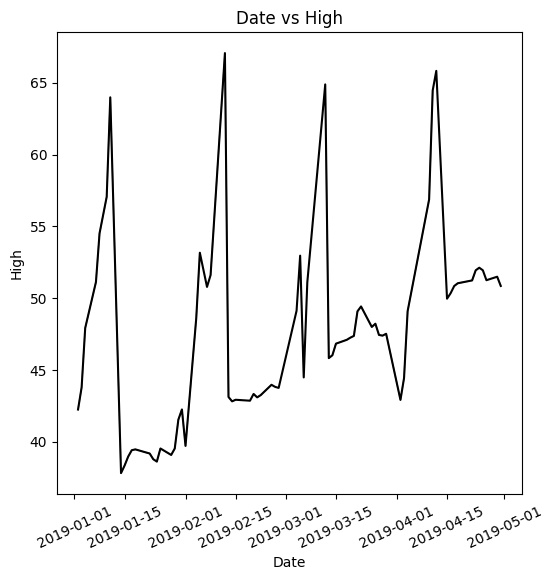

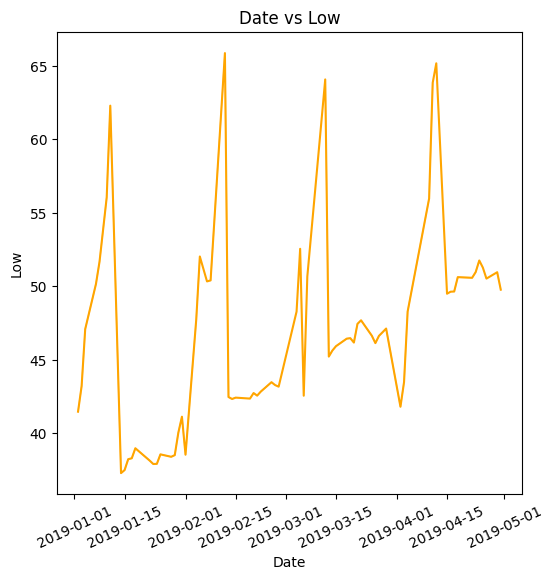

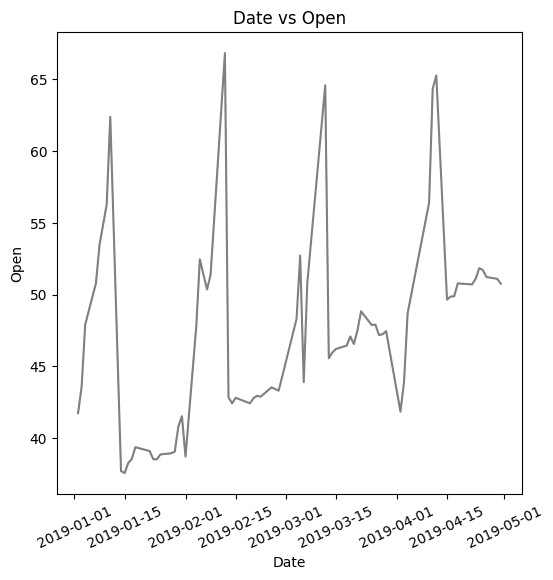

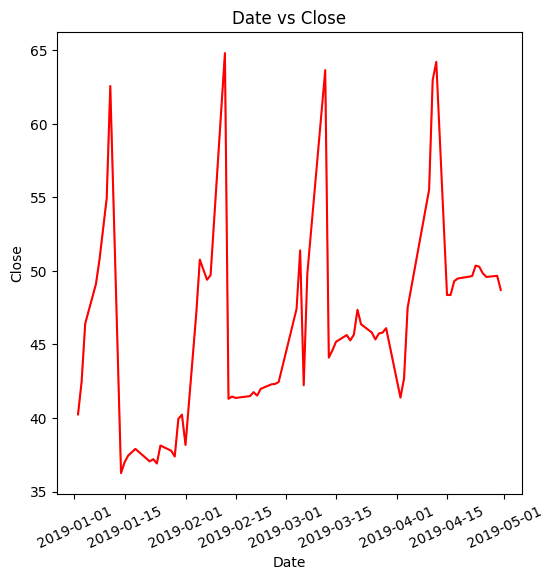

In [28]:
#Time Series Analysis (Date vs Price columns)
for col, vis in numeric_col1:
  plt.figure(figsize=(6,6))
  sns.lineplot(x='Date', y=col, data=data, color=vis)
  plt.title(f'Date vs {col}')
  plt.xlabel('Date')
  plt.ylabel(col)
  plt.xticks(rotation=25) # Rotate x-axis labels
  plt.show()

**In simple terms:** Plots each price variable over time (line chart against `Date`) to visualize the overall price trend.

### **Distribution of News Length Across Sentiment Categories**

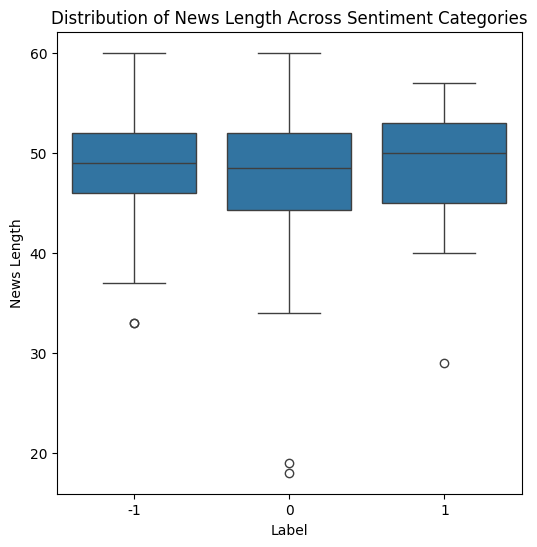

In [29]:
plt.figure(figsize=(6, 6))
sns.boxplot(x='Label', y='News_length', data=data)
plt.title('Distribution of News Length Across Sentiment Categories')
plt.xlabel('Label')
plt.ylabel('News Length')
plt.show()

**In simple terms:** Compares news article length across the three sentiment (`Label`) categories using a boxplot.

## **Data Preprocessing**

* Split the dataset into training and test sets using an **80:20** ratio with **train_test_split** (random_state=42) to ensure reproducibility.

* The feature matrix  **X** contains text embeddings generated from the embedding stage.

* The dimensionality of **X** varies depending on the embedding model used.

* For each embedding type, separate **X_train and X_test splits** were created, paired with the target **y_train, y_test**.

In [30]:
# Storing target variable
y = data['Label']

**In simple terms:** Stores the sentiment `Label` column as the target variable `y` that the models will try to predict.

## **Word Embeddings**


#### **Word2Vec**

In [31]:
# Creating a list of lists of words for the Word2Vec model
corpus = [sentence.split() for sentence in data['News']]

**In simple terms:** Splits each news article into a list of individual words, creating the text corpus needed to train Word2Vec.

In [32]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(corpus, min_count=2, window=5, vector_size=100, sg=1, hs=0, workers=4)

**In simple terms:** Trains a Word2Vec model on the corpus to learn 100-dimensional vector representations for words.

* Initializing the Word2Vec model
* min_count: Ignores all words with total frequency lower than this. 2 means words appearing only once or twice are ignored.
* window: The maximum distance between the current and predicted word within a sentence.
* vector_size: Dimensionality of the word vectors.
* sg: Training algorithm; 1 for skip-gram, 0 for CBOW.
* hs: If 1, hierarchical softmax will be used for model training. If 0 (default), negative sampling will be used.
* workers: Number of CPU cores to use for training.

In [33]:
# Retrieving word vectors for all the words present in the model's vocabulary
words = w2v_model.wv.index_to_key
vec_size = w2v_model.wv.vectors.shape[1]

# Creating a dictionary of words and their corresponding vectors
word_vector_dict = {word: w2v_model.wv[word] for word in words}

**In simple terms:** Retrieves the vector for every word the Word2Vec model learned and stores them in a word-to-vector dictionary.

In [34]:
def average_vectorizer_Word2Vec(doc):
    # Initializing a feature vector for the sentence
    feature_vector = np.zeros((vec_size,), dtype="float64")

    # Creating a list of words in the sentence that are present in the model vocabulary
    words_in_vocab = [word for word in doc.split() if word in words]

    # adding the vector representations of the words
    for word in words_in_vocab:
        feature_vector += np.array(word_vector_dict[word])

    # Dividing by the number of words to get the average vector
    if len(words_in_vocab) != 0:
        feature_vector /= len(words_in_vocab)

    return feature_vector

**In simple terms:** Defines a function that averages all word vectors in a news article into one single embedding vector for that article.

In [35]:
# creating a dataframe of the vectorized documents
X_Word2Vec_df = pd.DataFrame([average_vectorizer_Word2Vec(doc) for doc in data['News']])

**In simple terms:** Applies this averaging function to every article, producing a Word2Vec-based embedding table (`X_Word2Vec_df`) for the whole dataset.

## **Sentence Transformer**

####**Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 text embedding**

In [36]:
model = SentenceTransformer('BAAI/bge-base-en-v1.5')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/777 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/366 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

**In simple terms:** Loads the pretrained `BAAI/bge-base-en-v1.5` Sentence Transformer model for generating richer text embeddings.

##### Encoding the dataset

In [37]:
embedding_matrix = model.encode(data['News'])

**In simple terms:** Encodes every news article into a dense embedding vector using the BAAI transformer model.

In [38]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(349, 768)

**In simple terms:** The embedding matrix has shape **(349, 768)** — 349 articles, each represented by a 768-number vector.

## **Sentiment Analysis**

### **Model Evaluation Criterion**


- Plot a **confusion matrix** (`plot_confusion_matrix`)
- Generate key **classification metrics** like accuracy, recall, precision, and F1-score (`model_performance_classification_sklearn`)



##### **Utility Functions**

In [39]:
def plot_confusion_matrix(actual, predicted):
    """
    Plot a confusion matrix to visualize the performance of a classification model.

    Parameters:
    actual (array-like): The true labels.
    predicted (array-like): The predicted labels from the model.

    Returns:
    None: Displays the confusion matrix plot.
    """

    # Compute the confusion matrix.
    cm = confusion_matrix(actual, predicted)

    # Create a new figure with a specified size
    plt.figure(figsize=(5, 4))

    # Define the labels for the confusion matrix dynamically from the data
    label_list = sorted(list(np.unique(np.concatenate((actual, predicted)))))

    # Plot the confusion matrix using a heatmap with annotations
    sns.heatmap(cm, annot=True, fmt='.0f', cmap='Blues', xticklabels=label_list, yticklabels=label_list)

    # Label for the y-axis
    plt.ylabel('Actual')

    # Label for the x-axis
    plt.xlabel('Predicted')

    # Title of the plot
    plt.title('Confusion Matrix')

    # Display the plot
    plt.show()

**In simple terms:** Defines a reusable function to plot a confusion matrix comparing actual vs predicted sentiment labels.

In [40]:
def model_performance_classification_sklearn(actual, predicted):
    """
    Compute various performance metrics for a classification model using sklearn.

    Parameters:
    model (sklearn classifier): The classification model to evaluate.
    predictors (array-like): The independent variables used for predictions.
    target (array-like): The true labels for the dependent variable.

    Returns:
    pandas.DataFrame: A DataFrame containing the computed metrics (Accuracy, Recall, Precision, F1-score).
    """

    # Compute Accuracy
    acc = accuracy_score(actual,predicted)
    # Compute Recall
    recall = recall_score(actual,predicted,average='weighted')
    # Compute Precision
    precision = precision_score(actual,predicted,average='weighted')
    # Compute F1-score
    f1 = f1_score(actual,predicted,average='weighted')

    # Create a DataFrame to store the computed metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": [acc],
            "Recall": [recall],
            "Precision": [precision],
            "F1": [f1],
        }
    )
    # Return the DataFrame with the metrics
    return df_perf

**In simple terms:** Defines a reusable function to compute accuracy, recall, precision, and F1-score for a classifier.

## **Build Random Forest Models using different text embeddings**

### **Word2Vec-Random Forest Model**

In [41]:
# Storing independent variable
X = X_Word2Vec_df

**In simple terms:** Sets the Word2Vec embeddings as input features (X) for the first model.

In [42]:
from sklearn.model_selection import train_test_split

# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

**In simple terms:** Splits the Word2Vec features and labels into 80% training data and 20% test data.

In [43]:
# Building the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fitting on train data
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

**In simple terms:** Builds and trains a Random Forest classifier (100 trees) on the Word2Vec training data.

In [44]:
# Predicting on train data
y_pred_train = model.predict(X_train)

# Predicting on test data
y_pred_test = model.predict(X_test)


**In simple terms:** Uses the trained Random Forest model to predict sentiment labels on both train and test sets.

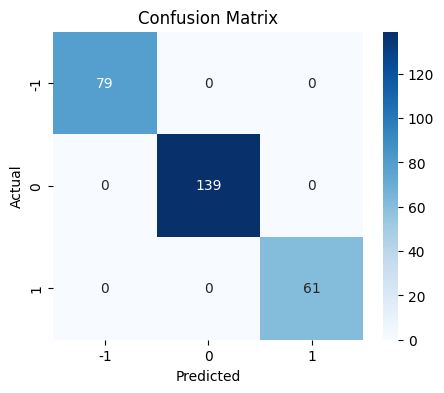

In [45]:
plot_confusion_matrix(y_train, y_pred_train)

**In simple terms:** Shows the confusion matrix for Random Forest predictions on the **training** data (Word2Vec).

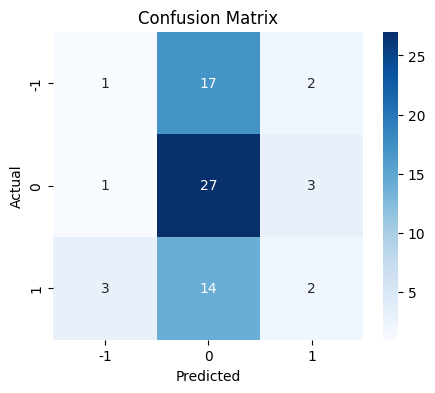

In [46]:
plot_confusion_matrix(y_test, y_pred_test)

**In simple terms:** Shows the confusion matrix for Random Forest predictions on the **test** data (Word2Vec).

In [47]:
train_Word2Vec_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_Word2Vec_RF.to_string(index=False))
test_Word2Vec_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_Word2Vec_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.428571 0.428571   0.340852 0.333315


**In simple terms:** Word2Vec + Random Forest scores a perfect **100% accuracy on training** but only **40% accuracy on test data** — a strong sign of overfitting.

###**Sentence Transformer-Random Forest Model**

In [48]:
# Storing independent variable
X = embedding_matrix


**In simple terms:** Sets the BAAI Sentence Transformer embeddings as input features (X) for the next model.

In [49]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**In simple terms:** Splits the BAAI transformer embeddings into training and test sets.

In [50]:
# Building the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fitting on train data
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

**In simple terms:** Builds and trains a new Random Forest classifier using the BAAI transformer embeddings.

In [51]:
# Predicting on train data
y_pred_train = model.predict(X_train)

# Predicting on test data
y_pred_test = model.predict(X_test)


**In simple terms:** Predicts sentiment on train and test sets using this transformer-based Random Forest model.

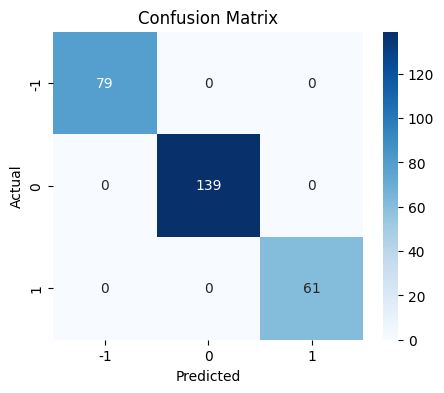

In [52]:
plot_confusion_matrix(y_train, y_pred_train)

**In simple terms:** Shows the confusion matrix for training predictions (BAAI Transformer + Random Forest).

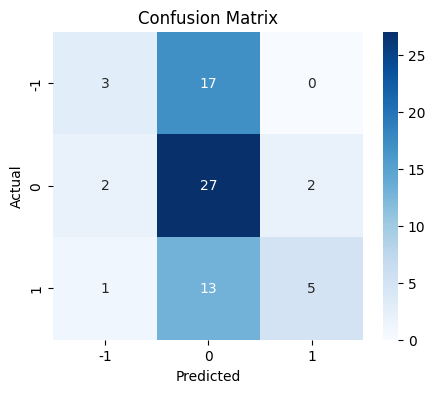

In [53]:
plot_confusion_matrix(y_test, y_pred_test)

**In simple terms:** Shows the confusion matrix for test predictions (BAAI Transformer + Random Forest).

In [54]:
train_transformer_BAAI_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_BAAI_RF)
test_transformer_BAAI_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_BAAI_RF.to_string(index=False))


Training set performance metrics:
   Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.5     0.5   0.546509 0.442083


**In simple terms:** BAAI Transformer + Random Forest again hits **100% training accuracy** but improves test accuracy slightly to **50%**, still overfitting but better than Word2Vec.

### **Building Neural Network Models using different text embeddings**

### **Word2Vec-Neural Network Model**

In [55]:
# Storing independent variable
X = X_Word2Vec_df

**In simple terms:** Sets the Word2Vec embeddings as input features for a neural network model.

In [56]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size = 0.2, random_state = 42)

**In simple terms:** Splits the Word2Vec features into train/test sets for the neural network.

In [57]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

**In simple terms:** Remaps sentiment labels from (-1, 0, 1) to (0, 1, 2) so the neural network can treat them as class categories.

In [58]:
# Building the model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax') # 3 output neurons for 3 classes
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)

**In simple terms:** Builds and compiles a neural network with a final layer of 3 neurons (one per sentiment class).

In [59]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4552 - loss: 1.0835 - val_accuracy: 0.4429 - val_loss: 1.0737
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0454 - val_accuracy: 0.4429 - val_loss: 1.0774
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0391 - val_accuracy: 0.4429 - val_loss: 1.0825
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0478 - val_accuracy: 0.4429 - val_loss: 1.0838
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4982 - loss: 1.0532 - val_accuracy: 0.4429 - val_loss: 1.0768
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4982 - loss: 1.0380 - val_accuracy: 0.4429 - val_loss: 1.0778
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4982 - loss: 1.0355 - val_accuracy: 0.4429 - val_loss: 1.0802
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4982 - loss: 1.0494 - val_accuracy: 0.4429 - val_loss: 1.0791


**In simple terms:** Trains the neural network for 20 epochs on the Word2Vec training data.

In [60]:
# Predict class probabilities  for training data
y_train_pred_probs = model.predict(X_train)

# Convert the predicted probabilities into class labels
y_train_preds = np.argmax(y_train_pred_probs, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


**In simple terms:** Predicts class probabilities on training data and converts them into final predicted labels.

In [61]:
# Predict class probabilities  for test data
y_test_pred_probs = model.predict(X_test)

# Convert the predicted probabilities into class labels
y_test_preds = np.argmax(y_test_pred_probs, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


**In simple terms:** Predicts class probabilities on test data and converts them into final predicted labels.

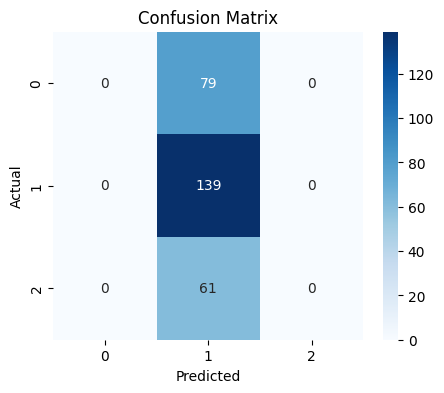

In [62]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

**In simple terms:** Shows the confusion matrix for the neural network's training predictions (Word2Vec).

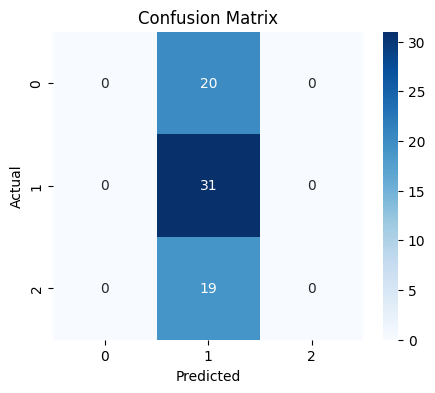

In [63]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

**In simple terms:** Shows the confusion matrix for the neural network's test predictions (Word2Vec).

In [64]:
train_Word2Vec_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_Word2Vec_NN .to_string(index=False))
test_Word2Vec_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_Word2Vec_NN .to_string(index=False))



Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


**In simple terms:** Word2Vec + Neural Network performs weakly overall — about **50% training accuracy** and **44% test accuracy**, with low precision/F1 (~0.2–0.3), meaning it struggles to tell classes apart.

### **Generating Embeddings with Sentence Tranformers using the BAAI/bge-base-en-v1.5 embedding -Neural Network model**

In [65]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**In simple terms:** Splits the BAAI transformer embeddings into train/test sets for a second neural network.

In [66]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

**In simple terms:** Remaps sentiment labels to (0, 1, 2) for this neural network as well.

In [67]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax')) # 3 output neurons for 3 classes

model.compile( optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,379 (83.51 KB)

 Trainable params: 21,379 (83.51 KB)

 Non-trainable params: 0 (0.00 B)

**In simple terms:** Clears the previous model from memory and builds a fresh neural network for the BAAI transformer embeddings.

In [68]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4086 - loss: 1.0817 - val_accuracy: 0.4429 - val_loss: 1.0748
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4946 - loss: 1.0475 - val_accuracy: 0.4429 - val_loss: 1.0825
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4982 - loss: 1.0493 - val_accuracy: 0.4429 - val_loss: 1.0892
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4982 - loss: 1.0505 - val_accuracy: 0.4429 - val_loss: 1.0826
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4982 - loss: 1.0562 - val_accuracy: 0.4429 - val_loss: 1.0782
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4982 - loss: 1.0510 - val_accuracy: 0.4429 - val_loss: 1.0786
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4982 - loss: 1.0472 - val_accuracy: 0.4429 - val_loss: 1.0794
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4982 - loss: 1.0446 - val_accuracy: 0.4429 - val_loss: 1.0776


**In simple terms:** Trains this neural network for 20 epochs on the BAAI transformer training data.

In [69]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_pred_probs,axis=1)


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


**In simple terms:** Predicts class probabilities on training data and converts them to final labels.

In [70]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_pred_probs,axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


**In simple terms:** Predicts class probabilities on test data and converts them to final labels.

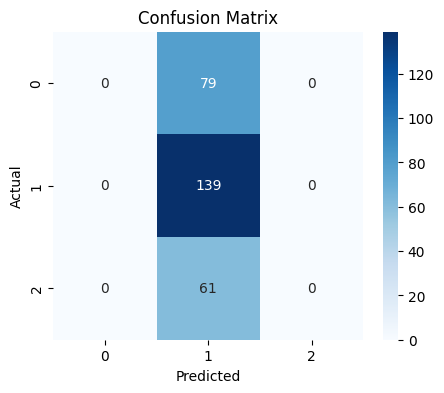

In [71]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

**In simple terms:** Shows the confusion matrix for training predictions (BAAI Transformer + Neural Network).

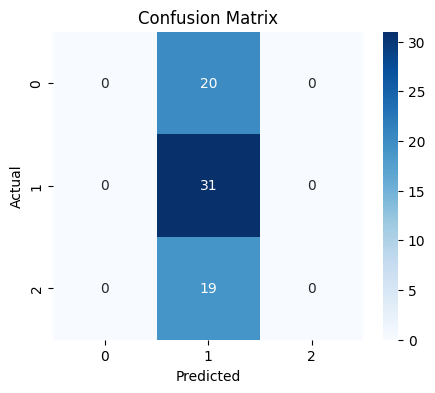

In [72]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

**In simple terms:** Shows the confusion matrix for test predictions (BAAI Transformer + Neural Network).

In [73]:
train_transformer_BAAI_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_BAAI_NN .to_string(index=False))
test_transformer_BAAI_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_BAAI_NN .to_string(index=False))


Training set performance metrics:
 Accuracy   Recall  Precision       F1
 0.498208 0.498208   0.248211 0.331344
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.442857 0.442857   0.196122 0.271853


**In simple terms:** BAAI Transformer + Neural Network gives the same result as the previous model — **~50% training accuracy** and **44% test accuracy**, still fairly weak.

#### **Generating Embeddings with Sentence Tranformers using the all-MiniLM-L6-v2 text embedding**

In [74]:
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

**In simple terms:** Loads a second, lighter pretrained Sentence Transformer model — `all-MiniLM-L6-v2` — for generating embeddings.

##### Encoding the dataset

In [75]:
embedding_matrix = model.encode(data['News'])

**In simple terms:** Encodes every news article into an embedding vector using the MiniLM model.

In [76]:
# printing the shape of the embedding matrix
embedding_matrix.shape

(349, 384)

**In simple terms:** The MiniLM embedding matrix has shape **(349, 384)** — smaller (384-dim) vectors than the BAAI model's 768-dim vectors.

### **Sentence Transformer-all-MiniLM-L6-v2-Random Forest Model**

In [77]:
# Storing independent variable
X = embedding_matrix

**In simple terms:** Sets the MiniLM embeddings as input features (X) for a Random Forest model.

In [78]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**In simple terms:** Splits the MiniLM embeddings into train and test sets.

In [79]:
# Building the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Fitting on train data
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**In simple terms:** Builds and trains a Random Forest classifier using the MiniLM embeddings.

In [80]:
# Predicting on train data
y_pred_train = model.predict(X_train)

# Predicting on test data
y_pred_test = model.predict(X_test)

**In simple terms:** Predicts sentiment on train and test sets using this MiniLM-based Random Forest model.

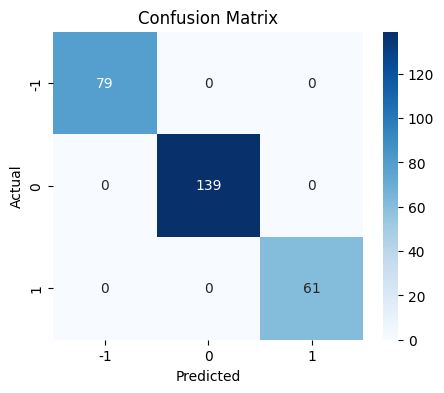

In [81]:
plot_confusion_matrix(y_train, y_pred_train)

**In simple terms:** Shows the confusion matrix for training predictions (MiniLM + Random Forest).

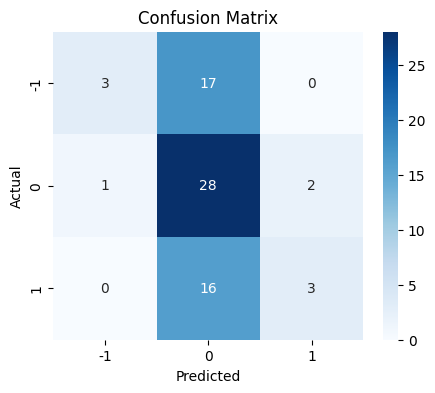

In [82]:
plot_confusion_matrix(y_test, y_pred_test)

**In simple terms:** Shows the confusion matrix for test predictions (MiniLM + Random Forest).

In [83]:
train_transformer_MiniLM_RF = model_performance_classification_sklearn(y_train,y_pred_train)
print("Training set performance metrics:")
print(train_transformer_MiniLM_RF.to_string(index=False))
test_transformer_MiniLM_RF = model_performance_classification_sklearn(y_test,y_pred_test)
print("Test set performance metrics:")
print(test_transformer_MiniLM_RF.to_string(index=False))

Training set performance metrics:
 Accuracy  Recall  Precision  F1
      1.0     1.0        1.0 1.0
Test set performance metrics:
 Accuracy   Recall  Precision       F1
 0.485714 0.485714   0.580422 0.408851


**In simple terms:** MiniLM + Random Forest again shows **100% training accuracy** but **~49% test accuracy** — overfitting, similar to the other Random Forest models.

### **Sentence Transformer-all-MiniLM-L6-v2-Neural Network Model**

In [84]:
# Storing independent variable
X = embedding_matrix

**In simple terms:** Sets the MiniLM embeddings as input features for a neural network model.

In [85]:
# Split data into training and testing set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**In simple terms:** Splits the MiniLM embeddings into train/test sets for the neural network.

In [86]:
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = np.array([label_map[y] for y in y_train])
y_test_mapped = np.array([label_map[y] for y in y_test])

**In simple terms:** Remaps sentiment labels to (0, 1, 2) for this neural network.

In [87]:
import gc

# Clear previous sessions
tf.keras.backend.clear_session()
gc.collect()

model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(3, activation='softmax')) # 3 output neurons for 3 classes

model.compile( optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,731 (225.51 KB)

 Trainable params: 57,731 (225.51 KB)

 Non-trainable params: 0 (0.00 B)

**In simple terms:** Clears memory and builds a fresh neural network for the MiniLM embeddings.

In [88]:
history = model.fit(
    X_train, y_train_mapped,
    validation_data=(X_test, y_test_mapped),
    epochs=20,
    batch_size=32
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.4480 - loss: 1.0827 - val_accuracy: 0.4857 - val_loss: 1.0664
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5161 - loss: 1.0462 - val_accuracy: 0.4714 - val_loss: 1.0473
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5197 - loss: 1.0051 - val_accuracy: 0.4429 - val_loss: 1.0318
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5090 - loss: 0.9701 - val_accuracy: 0.4429 - val_loss: 1.0209
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5341 - loss: 0.9207 - val_accuracy: 0.4857 - val_loss: 1.0024
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5591 - loss: 0.8977 - val_accuracy: 0.5429 - val_loss: 0.9791
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5663 - loss: 0.8679 - val_accuracy: 0.5429 - val_loss: 0.9608
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6201 - loss: 0.7872 - val_accuracy: 0.5286 - val_loss: 0.9372


**In simple terms:** Trains this neural network for 20 epochs on the MiniLM training data.

In [89]:
# Predict class probabilities on training data
y_train_pred_probs = model.predict(X_train)

# Convert probabilities to class labels
y_train_preds = np.argmax(y_train_pred_probs,axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


**In simple terms:** Predicts class probabilities on training data and converts them to final labels.

In [90]:
# Predict class probabilities on test data
y_test_pred_probs = model.predict(X_test)

# Convert probabilities to class labels
y_test_preds = np.argmax(y_test_pred_probs,axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


**In simple terms:** Predicts class probabilities on test data and converts them to final labels.

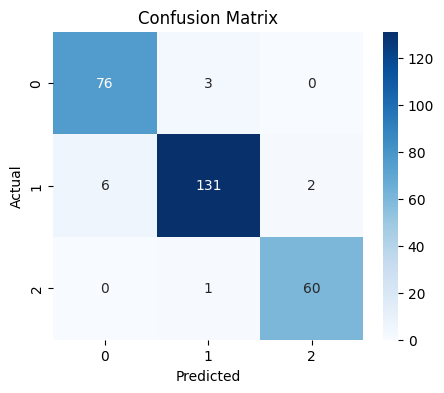

In [91]:
plot_confusion_matrix(y_train_mapped, y_train_preds)

**In simple terms:** Shows the confusion matrix for training predictions (MiniLM + Neural Network).

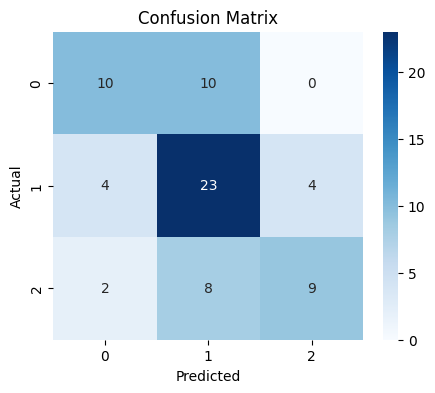

In [92]:
plot_confusion_matrix(y_test_mapped, y_test_preds)

**In simple terms:** Shows the confusion matrix for test predictions (MiniLM + Neural Network).

In [93]:
train_transformer_MiniLM_NN = model_performance_classification_sklearn(y_train_mapped, y_train_preds)
print("Training set performance metrics:")
print(train_transformer_MiniLM_NN.to_string(index=False))
test_transformer_MiniLM_NN  = model_performance_classification_sklearn(y_test_mapped, y_test_preds)
print("Test set performance metrics:")
print(test_transformer_MiniLM_NN.to_string(index=False))

Training set performance metrics:
 Accuracy   Recall  Precision      F1
 0.956989 0.956989   0.957467 0.95702
Test set performance metrics:
 Accuracy  Recall  Precision       F1
      0.6     0.6   0.614916 0.594345


**In simple terms:** MiniLM + Neural Network is the **best-generalizing model** -- ~**96% training accuracy and  ~59% test accuracy** (F1 ≈ 0.58), the smallest gap between train and test of all six models.

### **Model Performance Summary and Final Model Selection**

In [94]:
models_train_comp_df = pd.concat(
    [
        train_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        train_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        train_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        train_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        train_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_train_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,1.0,0.498208,1.0,0.498208,1.0,0.956989
Recall,1.0,0.498208,1.0,0.498208,1.0,0.956989
Precision,1.0,0.248211,1.0,0.248211,1.0,0.957467
F1,1.0,0.331344,1.0,0.331344,1.0,0.957020


**In simple terms:** Combines the training metrics of all 6 models (2 embeddings types × 3 embedding models × 2 classifiers) into one side-by-side comparison table — Random Forest models all show perfect (100%) training accuracy, hinting at overfitting.

In [95]:
# Concatenate the test performance metrics from different models into a single DataFrame
models_test_comp_df = pd.concat(
    [
        test_Word2Vec_RF.T,  # Random Forest using Word2Vec embeddings
        test_Word2Vec_NN.T,  # Neural Network using Word2Vec embeddings
        test_transformer_BAAI_RF.T,  # Random Forest using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_BAAI_NN.T, # Neural Network using Sentence-Transformer-BAAI/bge-base-en-v1.5 embeddings
        test_transformer_MiniLM_RF.T, # Random Forest using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
        test_transformer_MiniLM_NN.T   # Neural Network using Sentence-Transformer-all-MiniLM-L6-v2 embeddings
    ],
    axis=1  # Concatenate along columns (i.e., each model's metrics form one column)
)

# Assigning column names for each model
models_test_comp_df.columns = [
    "Word2Vec (Random Forest)",
    "Word2Vec (Neural Network)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest)",
    "Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Random Forest)",
    "Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)"
]

# Print the training performance comparison table
print("Test performance comparison:")
models_test_comp_df

Test performance comparison:


,Word2Vec (Random Forest),Word2Vec (Neural Network),Sentence Transformer-BAAI/bge-base-en-v1.5 (Random Forest),Sentence Transformer-BAAI/bge-base-en-v1.5 (Neural Network),Sentence Transformer-all-MiniLM-L6-v2 (Random Forest),Sentence Transformer-all-MiniLM-L6-v2 (Neural Network)
Accuracy,0.428571,0.442857,0.500000,0.442857,0.485714,0.600000
Recall,0.428571,0.442857,0.500000,0.442857,0.485714,0.600000
Precision,0.340852,0.196122,0.546509,0.196122,0.580422,0.614916
F1,0.333315,0.271853,0.442083,0.271853,0.408851,0.594345


**In simple terms:** Combines the test metrics of all 6 models into one table — **MiniLM + Neural Network** has the highest test accuracy (**58.6%**) and F1-score (**0.577**), making it the best-performing model on unseen data.

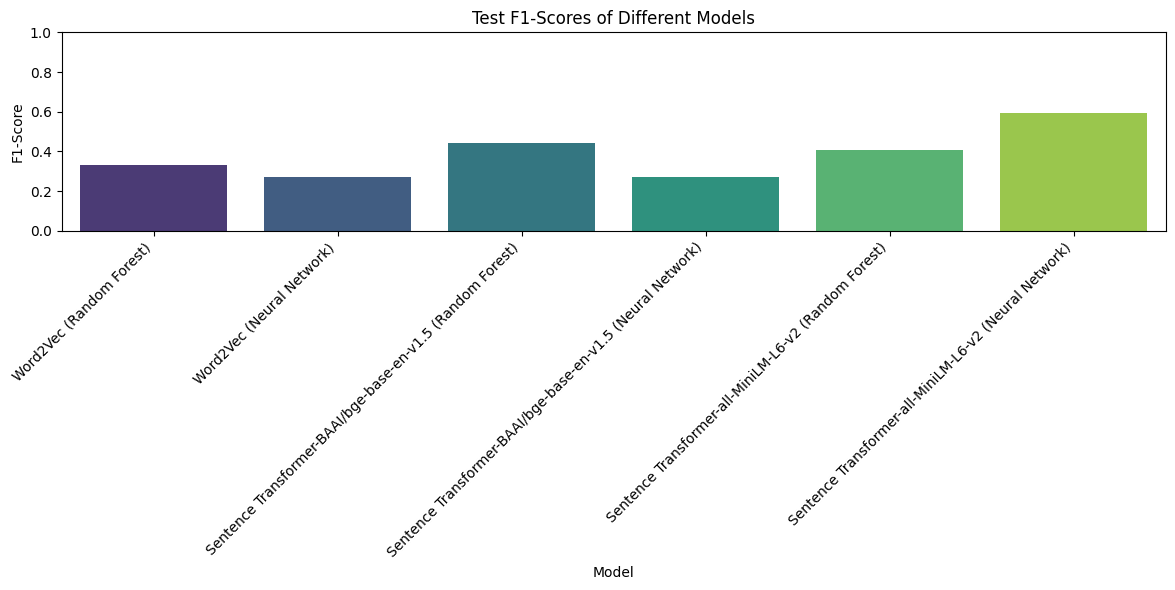

In [96]:
plt.figure(figsize=(12, 6))
sns.barplot(x=models_test_comp_df.columns, y=models_test_comp_df.loc['F1'].values, palette='viridis')
plt.title('Test F1-Scores of Different Models')
plt.xlabel('Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1) # F1-score ranges from 0 to 1
plt.tight_layout()
plt.show()

**In simple terms:** Plots a bar chart comparing the test F1-scores of all 6 models, visually confirming that MiniLM + Neural Network performs best.

#### **Final model with one prediction**

* Highest Performance on New Data: It achieved the best F1-score and accuracy on the test data, meaning it was the most effective at correctly classifying the sentiment of news articles it had never seen before.
* Better Generalization: Compared to other models, especially the Random Forests, it showed a much smaller difference between its performance on the training data and the test data. This indicates it learned robust patterns rather than just memorizing the training examples, making it less prone to overfitting.

In [98]:
import numpy as np

# Assuming `model` is the best-trained Neural Network model (MiniLM-L6-v2) from the previous cell.
# Assuming `X_test` is the test set for this model.
# Assuming `y_test_mapped` is the mapped true labels for the test set.

# Take the first sample from the test data
single_test_sample = X_test[0:1]

# Get the true label for this sample (mapped to 0, 1, or 2)
true_label_mapped = y_test_mapped[0]

# Get the true original label for this sample (-1, 0, or 1)
reverse_label_map = {0: -1, 1: 0, 2: 1}
true_label_original = reverse_label_map[true_label_mapped]

# Make a prediction with the model
predicted_probabilities = model.predict(single_test_sample)
predicted_label_mapped = np.argmax(predicted_probabilities, axis=1)[0]

# Map the predicted label back to the original sentiment scale (-1, 0, 1)
predicted_label_original = reverse_label_map[predicted_label_mapped]

print(f"Test Sample Input Shape: {single_test_sample.shape}")
print(f"Predicted probabilities for the sample: {predicted_probabilities[0]}")
print(f"Predicted label (mapped): {predicted_label_mapped}")
print(f"Predicted sentiment: {predicted_label_original}")
print(f"Actual sentiment: {true_label_original}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Test Sample Input Shape: (1, 384)
Predicted probabilities for the sample: [3.6227999e-03 9.9539113e-01 9.8609715e-04]
Predicted label (mapped): 1
Predicted sentiment: 0
Actual sentiment: 0


**IN SIMPLER TERMS**: This code predicts the sentiment of a single test news article using the best-performing MiniLM-L6-v2 Neural Network model and then displays both the predicted and actual sentiment for comparison.

<center><p float="center">
  <img src="https://i.postimg.cc/85kymfqQ/model-choice-impact.jpg" width="720"/>
</p></center>

## **Conclusions and Recommendations**

#### **Conclusions**



1.  **Word2Vec Embeddings:** Generally resulted in poorer model performance and significant overfitting, especially with Random Forest (100% train, 40% test accuracy).
2.  **Sentence Transformer Embeddings (BAAI & MiniLM):** Both improved performance over Word2Vec. `all-MiniLM-L6-v2` showed the best balance and generalization.
3.  **Neural Networks:** Demonstrated the best generalization, particularly with `all-MiniLM-L6-v2` embeddings, achieving the highest test F1-score (0.577).
4.  **Random Forest Models:** Consistently overfit the training data (100% training accuracy) across all embedding types, leading to much lower test performance (40-50%).

#### **Recommendations**




Based on the analysis:

1.  **Prioritize `all-MiniLM-L6-v2` embeddings with Neural Networks:** This combination provided the best performance and generalization.
2.  **Address Random Forest Overfitting:** Implement hyperparameter tuning and cross-validation for Random Forest to improve its test performance.
3.  **Explore Advanced Models & Data:** Investigate more sophisticated neural network architectures and consider data augmentation or acquiring more data to enhance model generalization.
4.  **Future Work & Integration:** Fine-tune embeddings for domain specificity and explore combining news sentiment with time-series stock data using multi-modal approaches for more accurate predictions.

# <font size=5.5 color="#4682B4"><b>THANK YOU</font>